<a href="https://colab.research.google.com/github/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/blob/main/Lab13/Lab13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 13**

In [63]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import logistic, norm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import set_config
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [64]:
url_data = "https://raw.githubusercontent.com/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/refs/heads/main/Lab13/Default.csv"

df = pd.read_csv(url_data)

## **Pregunta 1**

Presenta las primeras 5 y últimas 5 observaciones. ¿Cuál es el tipo de cada variable?

In [12]:
df.dtypes

,0
default,object
student,object
balance,float64
income,float64


In [13]:
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


## **Pregunta 2**

Construye un diagrama de caja que muestre la relación entre `default` y `balance`.

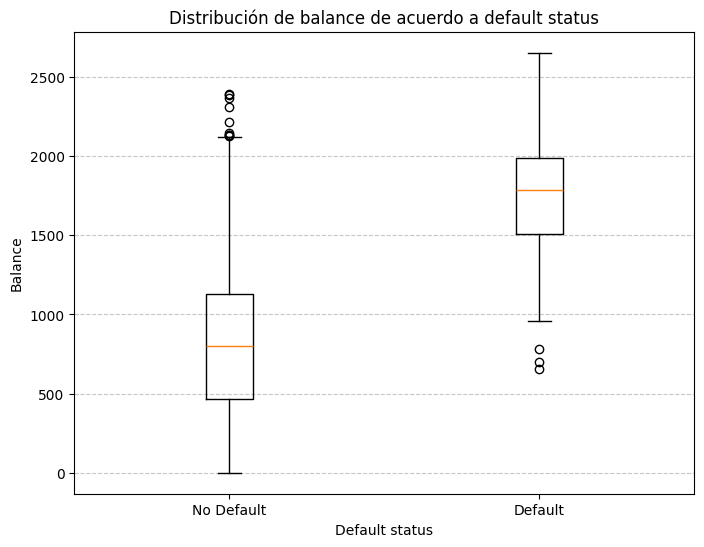

In [15]:
plt.figure(figsize=(8, 6))
plt.boxplot([df[df['default'] == 'No']['balance'], df[df['default'] == 'Yes']['balance']], tick_labels=['No Default', 'Default'])
plt.title('Distribución de balance de acuerdo a default status')
plt.xlabel('Default status')
plt.ylabel('Balance')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **Pregunta 3**

Construye un diagrama de caja que muestre la relación entre `default` y `income`.

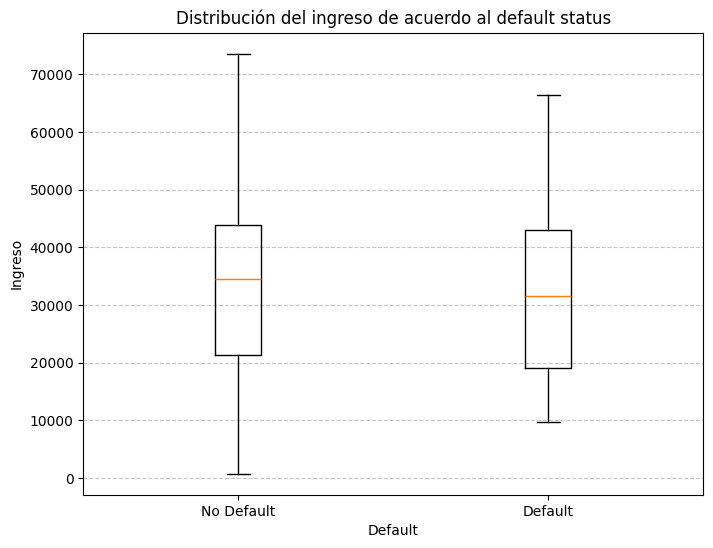

In [16]:
plt.figure(figsize=(8, 6))
plt.boxplot([df[df['default'] == 'No']['income'], df[df['default'] == 'Yes']['income']], tick_labels=['No Default', 'Default'])
plt.title('Distribución del ingreso de acuerdo al default status')
plt.xlabel('Default')
plt.ylabel('Ingreso')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **Pregunta 4**

(a) Construye una variable `no_pago^ a partir de la variable `default`:

- si `default=Yes`, entonces `no_pago=1`

- si `default=No`, entonces `no_pago=0`

(b) Construye una variable `estudiante^ a partir de la variable `student`:

- si `student=Yes`, entonces `estudiante=1`

- si `student=No`, entonces `estudiante=0`

In [65]:
df['no_pago'] = df['default'].apply(lambda x: 1 if x == 'Yes' else 0)

df['estudiante'] = df['student'].apply(lambda x: 1 if x == 'Yes' else 0)


In [66]:
df.head(10)

,default,student,balance,income,no_pago,estudiante
0,No,No,729.526495,44361.625074,0,0
1,No,Yes,817.180407,12106.134700,0,1
2,No,No,1073.549164,31767.138947,0,0
3,No,No,529.250605,35704.493935,0,0
4,No,No,785.655883,38463.495879,0,0
5,No,Yes,919.588530,7491.558572,0,1
6,No,No,825.513331,24905.226578,0,0
7,No,Yes,808.667504,17600.451344,0,1
8,No,No,1161.057854,37468.529288,0,0
9,No,No,0.000000,29275.268293,0,0


## **Pregunta 5**

Estima el modelo de probabilidad lineal:

$$default=\beta_0+\beta_1 balance+u$$

Usa errores estándar robustos a heterocedasticidad.

Usando un nivel de significancia de 5% ¿Qué variables son estadísticamente significativas?

In [67]:
modelo_pl = smf.ols('no_pago ~ balance', data=df).fit(cov_type = 'HC1')

print(modelo_pl.summary())

                            OLS Regression Results                            
Dep. Variable:                no_pago   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     397.7
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           8.28e-87
Time:                        11:31:36   Log-Likelihood:                 3644.8
No. Observations:               10000   AIC:                            -7286.
Df Residuals:                    9998   BIC:                            -7271.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0752      0.004    -18.657      0.0

## **Pregunta 6**

Calcula la *probabilidad de default* para cada una de las observaciones. Muestra las observaciones con probabilidades predichas negativas o mayores a 1.

In [68]:
df['prob_default_pred'] = modelo_pl.predict(df)

out_of_range_probs = df[(df['prob_default_pred'] < 0) | (df['prob_default_pred'] > 1)]

print("Observations with predicted probabilities < 0 or > 1:")
print(out_of_range_probs[['balance', 'income', 'estudiante', 'no_pago', 'prob_default_pred']].head())

print(f"\nTotal observations with out-of-range probabilities: {len(out_of_range_probs)}")

Observations with predicted probabilities < 0 or > 1:
       balance        income  estudiante  no_pago  prob_default_pred
3   529.250605  35704.493935           0        0          -0.006457
9     0.000000  29275.268293           0        0          -0.075192
10    0.000000  21871.073089           1        0          -0.075192
12  237.045114  28251.695345           0        0          -0.044406
15  286.232560  45042.413036           0        0          -0.038018

Total observations with out-of-range probabilities: 3123


## **Pregunta 7**

Estima el modelo logit:


$$P(Default = Yes | Balance)=\frac{exp(\beta_0+\beta_1\times Balance)}{1+exp(\beta_0+\beta_1\times Balance)}$$

Calcula el efecto marginal: PEA y APE.

In [69]:
modelo_logit = smf.logit('no_pago ~ balance', data=df).fit()
print(modelo_logit.summary())

Optimization terminated successfully.
         Current function value: 0.079823
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                no_pago   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Fri, 02 Oct 2026   Pseudo R-squ.:                  0.4534
Time:                        11:31:41   Log-Likelihood:                -798.23
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                6.233e-290
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.6513      0.361    -29.491      0.000     -11.359      -9.943
balance        0.0055      0

In [70]:
# Calcular efecto parcial en el promedio (PEA)
# Evalúa el efecto marginal en la media de las variables explicativas.
pea_logit = modelo_logit.get_margeff(at='mean', method='dydx')
print("\nEfectos Parciales en el Promedio (PEA) para 'balance':")
print(pea_logit.summary())




Efectos Parciales en el Promedio (PEA) para 'balance':
        Logit Marginal Effects       
Dep. Variable:                no_pago
Method:                          dydx
At:                              mean
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
balance     1.281e-05   1.87e-06      6.836      0.000    9.13e-06    1.65e-05


In [71]:
# Calcular promedio de efectos parciales (APE)
# Promedia los efectos marginales calculados para cada observación.
ape_logit = modelo_logit.get_margeff(at='overall', method='dydx')
print("\nEfectos Parciales Promedio (APE) para 'balance':")
print(ape_logit.summary())


Efectos Parciales Promedio (APE) para 'balance':
        Logit Marginal Effects       
Dep. Variable:                no_pago
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
balance        0.0001   4.72e-06     25.298      0.000       0.000       0.000


## **Problema 8**

Estima el modelo probit:

$$P(Default = Yes | Balance)=\Phi(\beta_0+\beta_1\times Balance)$$

Calcula el efecto marginal: PEA y APE.

In [72]:
modelo_probit = smf.probit('no_pago ~ balance', data=df).fit()
print(modelo_probit.summary())

Optimization terminated successfully.
         Current function value: 0.080276
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:                no_pago   No. Observations:                10000
Model:                         Probit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Fri, 02 Oct 2026   Pseudo R-squ.:                  0.4503
Time:                        11:31:48   Log-Likelihood:                -802.76
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                5.804e-288
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.3539      0.168    -31.861      0.000      -5.683      -5.025
balance        0.0027      0.

In [73]:
# Calcular efecto parcial en el promedio (PEA)
pea_probit = modelo_probit.get_margeff(at='mean', method='dydx')
print("\nEfectos Parciales en el Promedio (PEA) para 'balance' (Probit):")
print(pea_probit.summary())

# Calcular promedio de efectos parciales (APE)
ape_probit = modelo_probit.get_margeff(at='overall', method='dydx')
print("\nEfectos Parciales Promedio (APE) para 'balance' (Probit):")
print(ape_probit.summary())


Efectos Parciales en el Promedio (PEA) para 'balance' (Probit):
       Probit Marginal Effects       
Dep. Variable:                no_pago
Method:                          dydx
At:                              mean
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
balance     9.149e-06   1.99e-06      4.602      0.000    5.25e-06     1.3e-05

Efectos Parciales Promedio (APE) para 'balance' (Probit):
       Probit Marginal Effects       
Dep. Variable:                no_pago
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
balance        0.0001   4.94e-06     23.987      0.000       0.000       0.000


## **Problema 9**

Grafica la relación entre la probabilidad predicha de default y el saldo en la tarjeta de crédito en MPL, logit y probit.

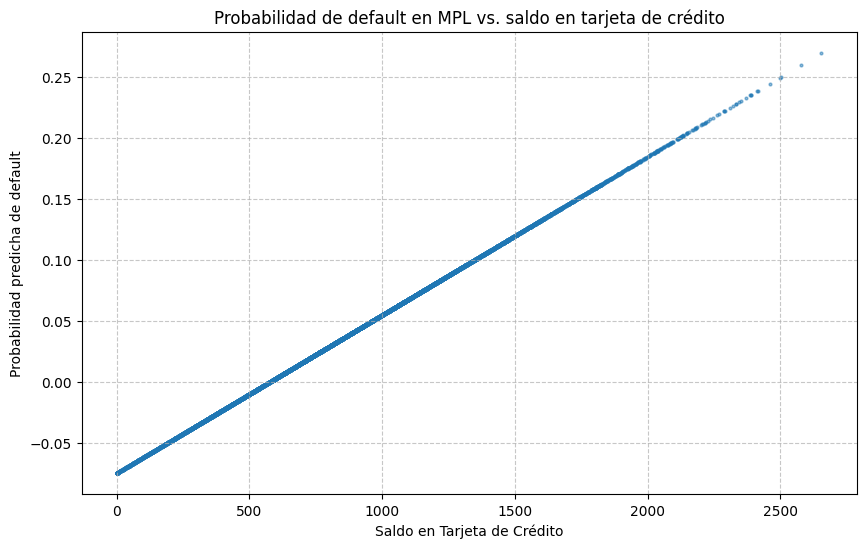

In [74]:
# Modelo de probabilidad lineal

plt.figure(figsize=(10, 6))
# Predecir probabilidades de default usando el modelo de probabilidad lineal
prob_default_lpm = modelo_pl.predict(df['balance'])

# Graficar las probabilidades predichas vs. el saldo
plt.scatter(df['balance'], prob_default_lpm, alpha=0.5, s=4)

plt.title('Probabilidad de default en MPL vs. saldo en tarjeta de crédito')
plt.xlabel('Saldo en Tarjeta de Crédito')
plt.ylabel('Probabilidad predicha de default')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

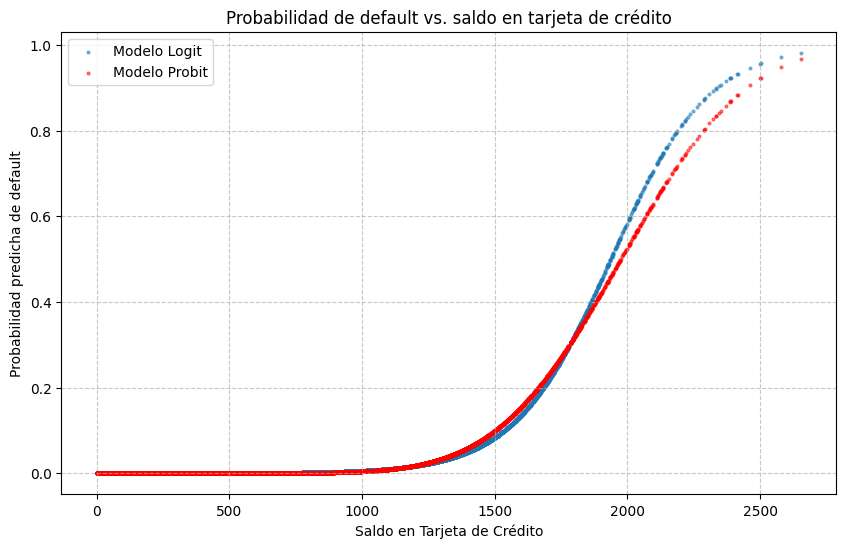

In [75]:
# Modelos logit y probit

plt.figure(figsize=(10, 6))

# Plotting Logit Model predictions
plt.scatter(df['balance'], modelo_logit.predict(df), alpha=0.5, s=4, label='Modelo Logit')

# Plotting Probit Model predictions
plt.scatter(df['balance'], modelo_probit.predict(df), alpha=0.5, s=4, label='Modelo Probit', color='red')

plt.title('Probabilidad de default vs. saldo en tarjeta de crédito')
plt.xlabel('Saldo en Tarjeta de Crédito')
plt.ylabel('Probabilidad predicha de default')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## **Pregunta 10**

Calcula la probabidad de default para una persona con un saldo en tarjeta de crédito de 2000 en los tres modelos. ¿Son iguales o diferentes las probabilidades predichas por los 3 modelos?

In [38]:
balance_value = 2000
# Crear un DataFrame para la predicción, ya que predict() espera un DataFrame
balance_df_lpm = pd.DataFrame({'balance': [balance_value]})

**Modelo de probabilidad lineal:**

$$P(Default = 1| Balance = 2000)=-0.07519 + 0.00013 \times 2000=0.1848\text{ o 18.5%}$$

In [40]:
# Calcular la probabilidad predicha usando el modelo de probabilidad lineal
prob_default_at_2000_lpm = modelo_pl.predict(balance_df_lpm)

print(f"La probabilidad de default si el saldo es {balance_value} es: {prob_default_at_2000_lpm.iloc[0]:.4f}")

La probabilidad de default si el saldo es 2000 es: 0.1846


**Modelo logit:**

$$P(Default = 1| Balance = 2000)=\frac{exp(-10.65+0.0055\times 2000)}{1+exp(-10.65+0.0055\times 2000)}=0.5866 \text{ o 58.7%}$$

In [41]:
# Calcular la probabilidad predicha usando el modelo logit
prob_default_at_2000 = modelo_logit.predict(pd.DataFrame({'balance': [2000]}))

print(f"La probabilidad de default si el saldo es 2000 es: {prob_default_at_2000.iloc[0]:.4f}")

La probabilidad de default si el saldo es 2000 es: 0.5858


**Modelo probit:**

$$P(Default=1|Balance=2000)=\Phi(−5.35+0.0027×2000)=\Phi(0.05)=0.5199 \text{ o 51.99%}$$

In [42]:
# Calcular la probabilidad predicha usando el modelo probit
prob_probit_2000 = modelo_probit.predict(pd.DataFrame({'balance': [2000]}))

print(f"La probabilidad de default si el saldo es 2000 es: {prob_probit_2000.iloc[0]:.4f}")

La probabilidad de default si el saldo es 2000 es: 0.5269


## **Pregunta 11**

Separa la muestra de 10000 observaciones entre training (80%) y test (20%) dataset ¿Qué proporción de default hay en ambos datasets?

In [44]:
# Divide el dataset en conjuntos de entrenamiento y prueba (80/20)
# 'no_pago' se usa como strata para asegurar que la proporción de 'default' sea la misma en ambos conjuntos
X = df[['balance']]  # Características, usando solo la columna 'balance'
y = df['no_pago']             # Variable objetivo numérica

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)}")
print(f"Tamaño del conjunto de prueba: {len(X_test)}")
print(f"Proporción de 'default=1' en el conjunto original: {y.value_counts(normalize=True)[1]:.4f}")
print(f"Proporción de 'default=1' en el conjunto de entrenamiento: {y_train.value_counts(normalize=True)[1]:.4f}")
print(f"Proporción de 'default=1' en el conjunto de prueba: {y_test.value_counts(normalize=True)[1]:.4f}")

Tamaño del conjunto de entrenamiento: 8000
Tamaño del conjunto de prueba: 2000
Proporción de 'default=1' en el conjunto original: 0.0333
Proporción de 'default=1' en el conjunto de entrenamiento: 0.0333
Proporción de 'default=1' en el conjunto de prueba: 0.0335


## **Pregunta 12**

Entrena el modelo logit con los datos de entrenamiento *(training dataset)*

In [49]:
set_config(display='text')

# Inicializar el modelo de regresión logística
modelo_clasificacion = LogisticRegression(random_state=42, solver='liblinear')

# Entrenar el modelo con los datos de entrenamiento
modelo_clasificacion.fit(X_train, y_train);


## **Pregunta 13**

Realiza predicciones de default en el test dataset.

In [52]:
# Realizar predicciones en el conjunto de prueba
y_pred = modelo_clasificacion.predict(X_test)

## **Pregunta 14**

Calcula la matriz de confusión usando un umbral, $p_0=0.5$.

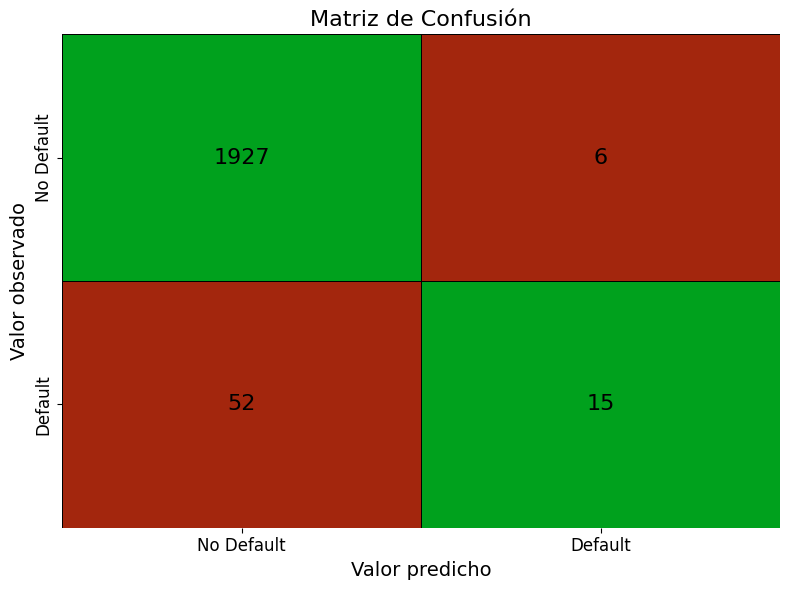

In [54]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Definir los colores deseados: verde para correctos, rojo para incorrectos
colors = ['#00A11D', '#A3260D']
cmap_custom = ListedColormap(colors)

# Crear una matriz auxiliar para el coloreado basado en la clasificación
# 0 para predicciones correctas (TN, TP)
# 1 para predicciones incorrectas (FP, FN)
colored_cm = np.array([
    [0, 1], # True Negative (0), False Positive (1)
    [1, 0]  # False Negative (1), True Positive (0)
])

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(colored_cm, annot=cm, fmt='d', cmap=cmap_custom,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            linewidths=.5, linecolor='black',
            annot_kws={'size': 16, 'color': 'white' if cmap_custom(0) == (0.0, 0.5, 0.0, 1.0) else 'black'},
            cbar=False)
plt.xlabel('Valor predicho', fontsize=14)
plt.ylabel('Valor observado', fontsize=14)
plt.title('Matriz de Confusión', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

## **Pregunta 15**

Usando la matriz de confusión obtenida en la *Pregunta 14*, calcula las métricas de recall, especificidad y accuracy.

In [58]:
# Definir una función para calcular la especificidad si aún no está definida
# (Se incluye aquí para asegurar que esté disponible, aunque ya debería estarlo en la celda anterior)
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

# Realizar predicciones en el conjunto de prueba (asumiendo y_pred y y_test están disponibles)
y_pred = modelo_clasificacion.predict(X_test)

# Calcular Recall
recall = recall_score(y_test, y_pred)
print(f"Recall (Sensibilidad): {recall:.4f}")

# Calcular Especificidad
specificity = specificity_score(y_test, y_pred)
print(f"Especificidad: {specificity:.4f}")

# Calcular Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión (Accuracy): {accuracy:.4f}")

Recall (Sensibilidad): 0.2239
Especificidad: 0.9969
Precisión (Accuracy): 0.9710


## **Pregunta 16**

Construye la matriz de confusión asumiendo un umbral $p_0=0.3$. Calcula las mismas métricas de la *Pregunta 15*.

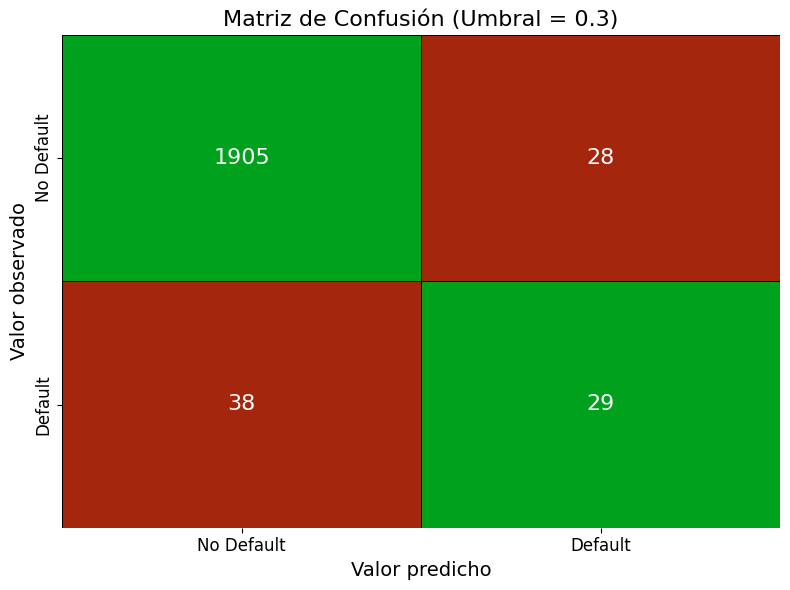

In [59]:
# Obtener las probabilidades de predicción para la clase positiva (default=1)
y_pred_proba = modelo_clasificacion.predict_proba(X_test)[:, 1]

# Aplicar el umbral de 0.3
umbral = 0.3
y_pred_thresholded = (y_pred_proba >= umbral).astype(int)

# Calcular la matriz de confusión con el nuevo umbral
cm = confusion_matrix(y_test, y_pred_thresholded)

# Definir los colores deseados: verde para correctos, rojo para incorrectos
colors = ['#00A11D', '#A3260D']
cmap_custom = ListedColormap(colors)

# Crear una matriz auxiliar para el coloreado basado en la clasificación
# 0 para predicciones correctas (TN, TP)
# 1 para predicciones incorrectas (FP, FN)
colored_cm = np.array([
    [0, 1], # True Negative (0), False Positive (1)
    [1, 0]  # False Negative (1), True Positive (0)
])

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(colored_cm, annot=cm, fmt='d', cmap=cmap_custom,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            linewidths=.5, linecolor='black',
            annot_kws={'size': 16, 'color': 'white'}, # Se usa blanco para que el texto sea legible sobre colores oscuros
            cbar=False)
plt.xlabel('Valor predicho', fontsize=14)
plt.ylabel('Valor observado', fontsize=14)
plt.title(f'Matriz de Confusión (Umbral = {umbral})', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [62]:
# Definir una función para calcular la especificidad si aún no está definida
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

# Usar las predicciones con el umbral de 0.3
y_pred_con_umbral = y_pred_thresholded # y_pred_thresholded ya fue calculado con umbral = 0.3

# Calcular Recall
recall = recall_score(y_test, y_pred_con_umbral)
print(f"Recall (Sensibilidad) con umbral de 0.3: {recall:.4f}")

# Calcular Especificidad
specificity = specificity_score(y_test, y_pred_con_umbral)
print(f"Especificidad con umbral de 0.3: {specificity:.4f}")

# Calcular Precisión (Accuracy)
accuracy = accuracy_score(y_test, y_pred_con_umbral)
print(f"Precisión (Accuracy) con umbral de 0.3: {accuracy:.4f}")

Recall (Sensibilidad) con umbral de 0.3: 0.4328
Especificidad con umbral de 0.3: 0.9855
Precisión (Accuracy) con umbral de 0.3: 0.9670


## **Pregunta 17**

Grafica la curva ROC y calcula el AUC.

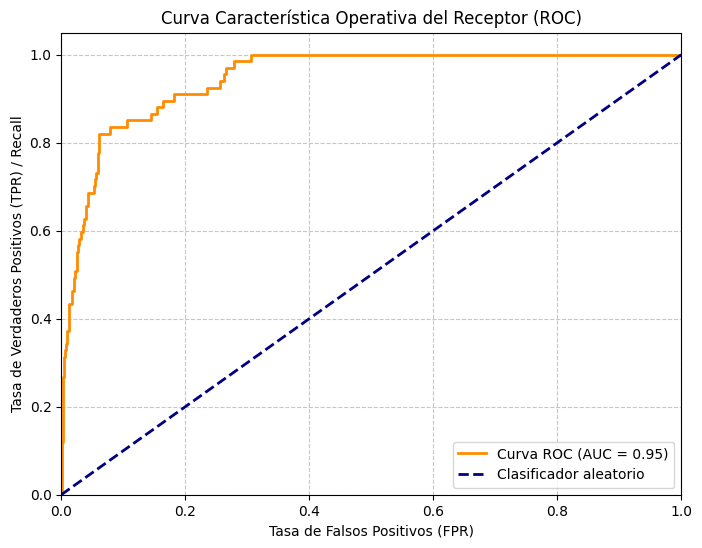

In [21]:
# Obtener las probabilidades de predicción para la clase positiva (default=1)
y_pred_proba = modelo_clasificacion.predict_proba(X_test)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR) / Recall')
plt.title('Curva Característica Operativa del Receptor (ROC)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()